# Parquet Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot
import time
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import polars as pl

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch, utils

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection, process_calohits_batch
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


2025-11-28 01:47:48,141 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-11-28 01:47:48,142 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-11-28 01:47:48,143 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-11-28 01:47:48,143 - DEBUG - h5py._conv - Creating converter from 5 to 7


## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


In [ ]:
# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]


In [ ]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v4")  # unified root like scripts

config = {
    "chunk_size": 10,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["tracker_hits", "particles", "tracks"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "tracks_columns_keep": tracks_columns_keep,
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}


In [ ]:
convert_all(config, chunk_index=0)

## Step-by-step Conversion

Roadmap:

- Convert a small set of edm4hep events to h5

In [4]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup"
dataset = "ttbar"
version = "v1"

base_root = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation")
output_base_dir = Path("./parquet_testing/v1")  # unified root like scripts
input_base_dir = base_root / campaign / dataset / version

# Configurable column selection for outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

calo_columns_keep = [
    "event_id", "detector", "cell_id", "total_energy", "x", "y", "z", "contrib_particle_ids",
    "contrib_energies", "contrib_times"
]


run_dir = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup/ttbar/v1/runs/0")

config = {
    "chunk_size": 10,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup",
    "dataset": "ttbar",
    "version": "v1",
    "common": {
        "output_base_dir": base_root,
        "input_base_dir": base_root
    },
    "objects": ["tracks", "tracker_hits", "particles", "calo_hits"],
    "min_tracker_hits": 1,
    "min_calo_hits": 1,
    "h5_output_dir": output_base_dir,
}

### Event lists and loading edm4hep events

In [5]:
from convert_all import *
from convert_all import _compute_paths, _prepare_output_dirs
from convert_digihits import *
from convert_tracks import *
from utils.path_utils import *
from utils.track_utils import *
from utils.driver import *
from utils.config import *


In [6]:
input_base_dir, output_base_dir, dataset_base, dataset_name_dot = _compute_paths(config)
particles_out_dir, trkhits_out_dir, tracks_out_dir, calo_out_dir = _prepare_output_dirs(output_base_dir, dataset_base, output_format="parquet")

In [7]:
particles_frames: list[pd.DataFrame] = []
digihits_frames: list[pd.DataFrame] = []
tracks_frames: list[pd.DataFrame] = []
seen_pairs_tracks: set[tuple[int, int]] = set()
seen_pairs_particles: set[tuple[int, int]] = set()
seen_pairs_hits: set[tuple[int, int]] = set()

In [8]:
run_size = 128
chunk_size = 10
run_dirs = get_run_paths(input_base_dir)
num_runs = len(run_dirs)
num_events = num_runs * run_size

In [9]:
input_base_dir

PosixPath('/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1')

In [10]:
chunk_index = 0

In [11]:
start_event = chunk_index * chunk_size
end_event = min(num_events, start_event + chunk_size) - 1
start_run = start_event // run_size
start_local = start_event % run_size
end_run = end_event // run_size
end_local = end_event % run_size

In [12]:
print(f"Start event: {start_event}, End event: {end_event}, Start run: {start_run}, End run: {end_run}, Start local: {start_local}, End local: {end_local}")

Start event: 0, End event: 9, Start run: 0, End run: 0, Start local: 0, End local: 9


In [13]:
abs_run = start_run
run_dir = run_dirs[abs_run]

In [14]:
local_events = local_events_for_run(
        start_run=start_run,
        start_local=start_local,
        end_run=end_run,
        end_local=end_local,
        abs_run=abs_run,
        run_size=run_size,
    )

In [15]:
local_events

(0, 10)

In [16]:
edm4hep_path = run_dir / "edm4hep.root"
batch = EDM4hepEventBatch(str(edm4hep_path), events=local_events, condense_calo=False)

2025-11-27 06:26:19,645 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root, events=(0, 10), full_load=False, condense_calo=False


In [17]:
batch._ensure_loaded("tracker_hits")
batch._ensure_loaded("calo_hits")
batch._ensure_loaded("calo_contributions")

2025-11-27 06:26:21,240 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=10
2025-11-27 06:26:21,242 - DEBUG - asyncio - Using selector: EpollSelector
2025-11-27 06:26:22,222 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=517352 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-27 06:26:23,525 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=487197 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-27 06:26:24,257 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=546469 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-27 06:26:25,246 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=491518 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-11-27 06:26:27,356 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=242472 cols=['event_id', 'subentry

### 0. Calo Loading

In [17]:
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
tracker_hits = batch.get_tracker_hits_df()

In [18]:
ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
ecal_time_min = -1.0  # ns
ecal_time_max = 10.0  # ns
hcal_time_min = -1.0  # ns
hcal_time_max = 10.0  # ns

run_calo_df = process_calohits_batch(
                    calo_hits,
                    calo_contributions,
                    ecal_energy_threshold=ecal_threshold_k4odd,
                    hcal_energy_threshold=hcal_threshold_k4odd,
                    time_min=ecal_time_min,
                    time_max=ecal_time_max,
                )

run_calo_df['event_id'] = run_calo_df['event_id'] + abs_run * run_size

2025-11-03 02:06:09,131 - DEBUG - convert_calorimeter - Batch: 26745279 contributions after timing filter
2025-11-03 02:06:18,267 - DEBUG - convert_calorimeter - Batch: 4825522 cells pass energy threshold
2025-11-03 02:06:29,438 - DEBUG - convert_calorimeter - Batch: processed 4825522 calorimeter cells in 23.119s


### Debug

In [22]:
%%time
# Test: Apply timing window to contributions, merge ALL, then threshold at cell level
print("=== Test: Threshold AFTER merging (cell level) ===\n")

ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
ecal_time_min = -1.0  # ns
ecal_time_max = 10.0  # ns
hcal_time_min = -1.0  # ns
hcal_time_max = 10.0  # ns

t0 = time.time()
calo_contributions['r'] = np.sqrt(calo_contributions['x']**2 + calo_contributions['y']**2 + calo_contributions['z']**2)
calo_contributions['dt'] = calo_contributions['r']/300 - 0.1  # in ns
print(f"Computed r and dt: {time.time() - t0:.3f}s")

t1 = time.time()
ecal_mask = calo_contributions['detector'].str.contains('ECal')
hcal_mask = calo_contributions['detector'].str.contains('HCal')
print(f"Masked detector regions: {time.time() - t1:.3f}s")

print(f"Contributions before any filtering: {len(calo_contributions)}")
print(f"Digi hits before any filtering: {len(calo_hits)}")

print(f"Shared unique cellIDs between calo_contributions and calo_hits: {len(calo_contributions.merge(calo_hits, on=['event_id', 'cellID']))}")

# Step 1: Apply timing cuts to contributions only (NOT energy)
t1 = time.time()
if 'time' in calo_contributions.columns:
    contributions_timing_filtered = calo_contributions[
    ((ecal_mask) &
        (calo_contributions['time'] - calo_contributions['dt'] >= ecal_time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= ecal_time_max)) |
    ((hcal_mask) & 
        (calo_contributions['time'] - calo_contributions['dt'] >= hcal_time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= hcal_time_max))
]
    print(f"Contributions after TIMING filter only: {len(contributions_timing_filtered)}")
    print(f"Timing filter took: {time.time() - t1:.3f}s")
else:
    contributions_timing_filtered = calo_contributions
    print("No timing filter (no time column)")

=== Test: Threshold AFTER merging (cell level) ===

Computed r and dt: 1.066s
Masked detector regions: 25.258s
Contributions before any filtering: 63055700
Digi hits before any filtering: 12959845
Shared unique cellIDs between calo_contributions and calo_hits: 63055700
Contributions after TIMING filter only: 26745279
Timing filter took: 3.664s
CPU times: user 40.4 s, sys: 23.9 s, total: 1min 4s
Wall time: 56.4 s


In [24]:
%%time
# Test: Apply timing window to contributions, merge ALL, then threshold at cell level
print("=== Test: Threshold AFTER merging (cell level) ===\n")

ecal_threshold_k4odd = 5.0e-5  # GeV
hcal_threshold_k4odd = 0.00025  # GeV
time_min = -1.0  # ns
time_max = 10.0  # ns

t0 = time.time()
calo_contributions['r'] = np.sqrt(calo_contributions['x']**2 + calo_contributions['y']**2 + calo_contributions['z']**2)
calo_contributions['dt'] = calo_contributions['r']/300 - 0.1  # in ns
print(f"Computed r and dt: {time.time() - t0:.3f}s")

print(f"Contributions before any filtering: {len(calo_contributions)}")
print(f"Digi hits before any filtering: {len(calo_hits)}")

# Step 1: Apply timing cuts to contributions only (NOT energy)
t1 = time.time()
if 'time' in calo_contributions.columns:
    contributions_timing_filtered = calo_contributions[
        (calo_contributions['time'] - calo_contributions['dt'] >= time_min) &
        (calo_contributions['time'] - calo_contributions['dt'] <= time_max)
    ]
    print(f"Contributions after TIMING filter only: {len(contributions_timing_filtered)}")
    print(f"Timing filter took: {time.time() - t1:.3f}s")
else:
    contributions_timing_filtered = calo_contributions
    print("No timing filter (no time column)")

=== Test: Threshold AFTER merging (cell level) ===

Computed r and dt: 1.049s
Contributions before any filtering: 63055700
Digi hits before any filtering: 12959845
Contributions after TIMING filter only: 26745279
Timing filter took: 3.361s
CPU times: user 4.07 s, sys: 5.88 s, total: 9.95 s
Wall time: 4.41 s


### Testing Nested Calorimeter Structure

Now let's test the full workflow:
1. Filter contributions by timing
2. Aggregate by (event_id, cellID, particle_id) 
3. Group to cell level with nested contributions
4. Merge with calo_hits to get positions
5. Apply cell-level energy threshold

In [25]:
%%time
# Step 1: Apply timing filters to contributions (already have this from above)
print(f"Contributions after timing filter: {len(contributions_timing_filtered)}")

# Step 2: Aggregate by (event_id, cellID, particle_id) with energy-weighted time
contributions_timing_filtered['energy_time'] = contributions_timing_filtered['energy'] * contributions_timing_filtered['time']

contrib_per_particle = (
    contributions_timing_filtered.groupby(['event_id', 'cellID', 'particle_id'], sort=False)
    .agg(
        energy=('energy', 'sum'),
        energy_time=('energy_time', 'sum'),
        detector=('detector', 'first'),
    )
    .reset_index()
)

# Calculate energy-weighted time per particle contribution
contrib_per_particle['time'] = contrib_per_particle['energy_time'] / contrib_per_particle['energy']
contrib_per_particle = contrib_per_particle.drop(columns=['energy_time'])

print(f"Particle contributions per cell: {len(contrib_per_particle)}")
contrib_per_particle.head()

Contributions after timing filter: 26745279


<timed exec>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Particle contributions per cell: 6823730
CPU times: user 4.91 s, sys: 2.24 s, total: 7.15 s
Wall time: 6.76 s


,event_id,cellID,particle_id,energy,detector,time
0,0,18302910442232025104,75527,0.000064,ECalBarrelCollection,17.505346
1,0,18303191917208735760,75527,0.000259,ECalBarrelCollection,17.506691
2,0,18358360995464742928,75603,0.000004,ECalBarrelCollection,13.332866
3,0,18355264805080729616,75603,0.000024,ECalBarrelCollection,15.578754
4,0,18357798054102239248,75603,0.000209,ECalBarrelCollection,16.551159


In [26]:
%%time
# Step 3a: First group by cell to get total energy (for threshold)
t_3a = time.time()
cell_energy = (
    contrib_per_particle.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
    )
    .reset_index()
)
print(f"Step 3a (cell grouping): {time.time() - t_3a:.3f}s")
print(f"Cells before energy threshold: {len(cell_energy)}")

# Step 3b: Apply cell-level energy thresholds BEFORE creating nested lists
t_3b = time.time()
ecal_mask = cell_energy['detector'].str.contains('ECal', na=False)
hcal_mask = cell_energy['detector'].str.contains('HCal', na=False)

energy_threshold_mask = (
    (ecal_mask & (cell_energy['total_energy'] >= ecal_threshold_k4odd)) |
    (hcal_mask & (cell_energy['total_energy'] >= hcal_threshold_k4odd))
)

cells_passing_threshold = cell_energy[energy_threshold_mask][['event_id', 'cellID']].copy()
print(f"Step 3b (energy threshold): {time.time() - t_3b:.3f}s")
print(f"Cells after energy threshold: {len(cells_passing_threshold)}")

# Step 3c: Filter contributions to only cells passing threshold, THEN create nested lists
t_3c = time.time()
contrib_filtered = contrib_per_particle.merge(
    cells_passing_threshold,
    on=['event_id', 'cellID'],
    how='inner'
)
print(f"Step 3c (filter contributions): {time.time() - t_3c:.3f}s")
print(f"Contributions after filtering to passing cells: {len(contrib_filtered)}")

# Step 3d: Now group to create nested lists (much smaller dataset!)
t_3d = time.time()
cell_level = (
    contrib_filtered.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
        contrib_particle_ids=('particle_id', list),
        contrib_energies=('energy', list),
        contrib_times=('time', list),
    )
    .reset_index()
)
print(f"Step 3d (nested grouping): {time.time() - t_3d:.3f}s")
print(f"Cells with nested contributions: {len(cell_level)}")
print(f"\nExample cell with contributions:")
print(cell_level.iloc[0])
print(f"\nNumber of contributions in first cell: {len(cell_level.iloc[0]['contrib_particle_ids'])}")

Step 3a (cell grouping): 2.376s
Cells before energy threshold: 5323056
Step 3b (energy threshold): 2.474s
Cells after energy threshold: 4825522
Step 3c (filter contributions): 3.296s
Contributions after filtering to passing cells: 6309571
Step 3d (nested grouping): 143.738s
Cells with nested contributions: 4825522

Example cell with contributions:
event_id                                      0
cellID                     18302910442232025104
detector                   ECalBarrelCollection
total_energy                           0.000064
contrib_particle_ids                    [75527]
contrib_energies        [6.367175956256688e-05]
contrib_times              [17.505346298217773]
Name: 0, dtype: object

Number of contributions in first cell: 1
CPU times: user 2min 25s, sys: 6.85 s, total: 2min 31s
Wall time: 2min 31s


In [29]:
%%time
# Step 3a: First group by cell to get total energy (for threshold)
t_3a = time.time()
cell_energy = (
    contrib_per_particle.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
    )
    .reset_index()
)
print(f"Step 3a (cell grouping): {time.time() - t_3a:.3f}s")
print(f"Cells before energy threshold: {len(cell_energy)}")

# Step 3b: Apply cell-level energy thresholds BEFORE creating nested lists
t_3b = time.time()
ecal_mask = cell_energy['detector'].str.contains('ECal', na=False)
hcal_mask = cell_energy['detector'].str.contains('HCal', na=False)

energy_threshold_mask = (
    (ecal_mask & (cell_energy['total_energy'] >= ecal_threshold_k4odd)) |
    (hcal_mask & (cell_energy['total_energy'] >= hcal_threshold_k4odd))
)

cells_passing_threshold = cell_energy[energy_threshold_mask][['event_id', 'cellID']].copy()
print(f"Step 3b (energy threshold): {time.time() - t_3b:.3f}s")
print(f"Cells after energy threshold: {len(cells_passing_threshold)}")

# Step 3c: Filter contributions to only cells passing threshold, THEN create nested lists
t_3c = time.time()
contrib_filtered = contrib_per_particle.merge(
    cells_passing_threshold,
    on=['event_id', 'cellID'],
    how='inner'
)
print(f"Step 3c (filter contributions): {time.time() - t_3c:.3f}s")
print(f"Contributions after filtering to passing cells: {len(contrib_filtered)}")

# Step 3d: Now group to create nested lists (much smaller dataset!)
t_3d = time.time()
cell_level = (
    contrib_filtered.groupby(['event_id', 'cellID'], sort=False)
    .agg(
        detector=('detector', 'first'),
        total_energy=('energy', 'sum'),
        contrib_particle_ids=('particle_id', list),
        contrib_energies=('energy', list),
        contrib_times=('time', list),
    )
    .reset_index()
)
print(f"Step 3d (nested grouping): {time.time() - t_3d:.3f}s")
print(f"Cells with nested contributions: {len(cell_level)}")
print(f"\nExample cell with contributions:")
print(cell_level.iloc[0])
print(f"\nNumber of contributions in first cell: {len(cell_level.iloc[0]['contrib_particle_ids'])}")

Step 3a (cell grouping): 2.534s
Cells before energy threshold: 5323056
Step 3b (energy threshold): 2.420s
Cells after energy threshold: 4825522
Step 3b (energy threshold): 2.420s
Cells after energy threshold: 4825522
Step 3c (filter contributions): 3.143s
Contributions after filtering to passing cells: 6309571
Step 3c (filter contributions): 3.143s
Contributions after filtering to passing cells: 6309571
Step 3d (nested grouping): 141.641s
Cells with nested contributions: 4825522

Example cell with contributions:
event_id                                      0
cellID                     18302910442232025104
detector                   ECalBarrelCollection
total_energy                           0.000064
contrib_particle_ids                    [75527]
contrib_energies        [6.367175956256688e-05]
contrib_times              [17.505346298217773]
Name: 0, dtype: object

Number of contributions in first cell: 1
CPU times: user 2min 23s, sys: 6.44 s, total: 2min 29s
Wall time: 2min 29s
Step 3

In [30]:
%%time
# POLARS VERSION - Much faster!
import polars as pl

print("=== Using Polars for fast grouping ===\n")

# Convert to Polars DataFrame
t_convert = time.time()
contrib_pl = pl.from_pandas(contrib_per_particle)
print(f"Convert to Polars: {time.time() - t_convert:.3f}s")

# Step 3a: Group by cell to get total energy (for threshold)
t_3a = time.time()
cell_energy_pl = (
    contrib_pl
    .group_by(['event_id', 'cellID'])
    .agg([
        pl.col('detector').first(),
        pl.col('energy').sum().alias('total_energy'),
    ])
)
print(f"Step 3a (cell grouping with Polars): {time.time() - t_3a:.3f}s")
print(f"Cells before energy threshold: {len(cell_energy_pl)}")

# Step 3b: Apply cell-level energy thresholds
t_3b = time.time()
cells_passing_pl = cell_energy_pl.filter(
    ((pl.col('detector').str.contains('ECal')) & (pl.col('total_energy') >= ecal_threshold_k4odd)) |
    ((pl.col('detector').str.contains('HCal')) & (pl.col('total_energy') >= hcal_threshold_k4odd))
).select(['event_id', 'cellID'])
print(f"Step 3b (energy threshold with Polars): {time.time() - t_3b:.3f}s")
print(f"Cells after energy threshold: {len(cells_passing_pl)}")

# Step 3c: Filter contributions to only cells passing threshold
t_3c = time.time()
contrib_filtered_pl = contrib_pl.join(cells_passing_pl, on=['event_id', 'cellID'], how='inner')
print(f"Step 3c (filter contributions with Polars): {time.time() - t_3c:.3f}s")
print(f"Contributions after filtering to passing cells: {len(contrib_filtered_pl)}")

# Step 3d: Create nested lists (this is the slow part in pandas, but fast in Polars!)
t_3d = time.time()
cell_level_pl = (
    contrib_filtered_pl
    .group_by(['event_id', 'cellID'])
    .agg([
        pl.col('detector').first(),
        pl.col('energy').sum().alias('total_energy'),
        pl.col('particle_id').alias('contrib_particle_ids'),
        pl.col('energy').alias('contrib_energies'),
        pl.col('time').alias('contrib_times'),
    ])
)
print(f"Step 3d (nested grouping with Polars): {time.time() - t_3d:.3f}s")
print(f"Cells with nested contributions: {len(cell_level_pl)}")

# Convert back to pandas for compatibility with rest of pipeline
t_convert_back = time.time()
cell_level_2 = cell_level_pl.to_pandas()
print(f"Convert back to pandas: {time.time() - t_convert_back:.3f}s")

print(f"\nExample cell with contributions:")
print(cell_level.iloc[0])
print(f"\nNumber of contributions in first cell: {len(cell_level.iloc[0]['contrib_particle_ids'])}")

=== Using Polars for fast grouping ===

Convert to Polars: 0.712s
Convert to Polars: 0.712s
Step 3a (cell grouping with Polars): 0.223s
Cells before energy threshold: 5323056
Step 3a (cell grouping with Polars): 0.223s
Cells before energy threshold: 5323056
Step 3b (energy threshold with Polars): 0.878s
Cells after energy threshold: 4825522
Step 3b (energy threshold with Polars): 0.878s
Cells after energy threshold: 4825522
Step 3c (filter contributions with Polars): 0.226s
Contributions after filtering to passing cells: 6309571
Step 3c (filter contributions with Polars): 0.226s
Contributions after filtering to passing cells: 6309571
Step 3d (nested grouping with Polars): 0.448s
Cells with nested contributions: 4825522
Convert back to pandas: 3.101s

Example cell with contributions:
event_id                                      0
cellID                     18302910442232025104
detector                   ECalBarrelCollection
total_energy                           0.000064
contrib_partic

In [33]:
cell_level

,event_id,cellID,detector,total_energy,contrib_particle_ids,contrib_energies,contrib_times
0,0,18302910442232025104,ECalBarrelCollection,0.000064,[75527],[6.367175956256688e-05],[17.505346298217773]
1,0,18303191917208735760,ECalBarrelCollection,0.000259,[75527],[0.0002594864636193961],[17.506690979003906]
2,0,18357798054102239248,ECalBarrelCollection,0.000209,[75603],[0.00020931375911459327],[16.551158905029297]
3,0,18357235125622474768,ECalBarrelCollection,0.000416,[75603],[0.00041606323793530464],[14.446691513061523]
4,0,18356953620581451792,ECalBarrelCollection,0.000331,[75603],[0.00033088267082348466],[13.574856758117676]
...,...,...,...,...,...,...,...
4825517,9,18442803389689254164,HCalEndcapCollection,0.000950,[236396],[0.0009499581065028906],[17.869518280029297]
4825518,9,18442240439735767316,HCalEndcapCollection,0.001224,[236396],[0.0012236012844368815],[17.904647827148438]
4825519,9,18441677554206923028,HCalEndcapCollection,0.001546,[236396],[0.0015459926798939705],[22.948339462280273]
4825520,9,18441677541321953556,HCalEndcapCollection,0.002940,[236398],[0.0029396391473710537],[21.365127563476562]


In [34]:
cell_level_2

,event_id,cellID,detector,total_energy,contrib_particle_ids,contrib_energies,contrib_times
0,6,18426759333200677393,ECalEndcapCollection,0.000367,"[235460, 235462]","[0.00022107625, 0.00014598572]","[13.136075, 13.138099]"
1,0,18436892359349836305,ECalEndcapCollection,0.000392,[170204],[0.0003921317],[14.040844]
2,5,9851778820870673,ECalEndcapCollection,0.000213,[163626],[0.00021317408],[18.951563]
3,1,18417752129651229201,ECalEndcapCollection,0.006066,[90836],[0.0060663046],[19.574556]
4,7,18373560678565890064,ECalBarrelCollection,0.000307,[186978],[0.000307134],[6.4486766]
...,...,...,...,...,...,...,...
4825517,4,18421974331611882001,ECalEndcapCollection,0.000164,[217671],[0.00016364438],[13.538952]
4825518,9,39124987422324752,ECalBarrelCollection,0.000410,[88276],[0.0004103183],[12.18223]
4825519,9,18305162297880952848,ECalBarrelCollection,0.000704,[226690],[0.00070357055],[11.884249]
4825520,9,48695106563825680,ECalBarrelCollection,0.000169,[235244],[0.00016937012],[6.9863834]


In [36]:
merged_cells = cell_level.merge(cell_level_2, on=["event_id", "cellID"])

In [37]:
merged_cells.columns

Index(['event_id', 'cellID', 'detector_x', 'total_energy_x',
       'contrib_particle_ids_x', 'contrib_energies_x', 'contrib_times_x',
       'detector_y', 'total_energy_y', 'contrib_particle_ids_y',
       'contrib_energies_y', 'contrib_times_y'],
      dtype='object')

In [21]:
%%time
# Step 4: Merge with calo_hits to get cell positions (x, y, z)
calo_cells = cell_level.merge(
    calo_hits[['event_id', 'cellID', 'x', 'y', 'z']],
    on=['event_id', 'cellID'],
    how='inner'
)

calo_cells.rename(columns={"cellID": "cell_id"}, inplace=True)

print(f"Final cells after merging with calo_hits: {len(calo_cells)}")
print(f"Columns: {calo_cells.columns.tolist()}")
calo_cells.head()

Final cells after merging with calo_hits: 4825522
Columns: ['event_id', 'cell_id', 'detector', 'total_energy', 'contrib_particle_ids', 'contrib_energies', 'contrib_times', 'x', 'y', 'z']
CPU times: user 4.44 s, sys: 1.9 s, total: 6.34 s
Wall time: 6.34 s


,event_id,cell_id,detector,total_energy,contrib_particle_ids,contrib_energies,contrib_times,x,y,z
0,0,18302910442232025104,ECalBarrelCollection,0.000064,[75527],[6.367175956256688e-05],[17.505346298217773],96.900002,-1282.699951,-2606.100098
1,0,18303191917208735760,ECalBarrelCollection,0.000259,[75527],[0.0002594864636193961],[17.506690979003906],96.900002,-1282.699951,-2601.000000
2,0,18357798054102239248,ECalBarrelCollection,0.000209,[75603],[0.00020931375911459327],[16.551158905029297],617.349609,-1263.855835,-1611.599976
3,0,18357235125622474768,ECalBarrelCollection,0.000416,[75603],[0.00041606323793530464],[14.446691513061523],606.122620,-1170.116699,-1621.800049
4,0,18356953620581451792,ECalBarrelCollection,0.000331,[75603],[0.00033088267082348466],[13.574856758117676],586.667969,-1216.437744,-1626.900024


### 1. Particle Loading

In [18]:
%%time
parts_all = batch.get_particles_df()
parents_all = batch.get_parents_df()

2025-11-27 06:27:42,204 - DEBUG - pyedm4hep.event_batch - _load_particles_and_links: start=0, stop=10


2025-11-27 06:27:45,025 - DEBUG - pyedm4hep.event_batch - particles columns after rename: ['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end'] rows=2263494
2025-11-27 06:27:45,026 - INFO - pyedm4hep.event_batch -   ↳ particles loaded: 2.8215s (2263494 rows)
2025-11-27 06:27:46,336 - INFO - pyedm4hep.event_batch -   ↳ links loaded: 1.2200s (parents=3949739, daughters=0)
2025-11-27 06:27:46,337 - INFO - pyedm4hep.event_batch - ⏱️  _load_particles_and_links: 4.2462s total
2025-11-27 06:27:46,338 - DEBUG - pyedm4hep.event_batch - augment_particles: input particles rows=2263494, cols=['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end', 'vr', 'energy', 'kinetic_energy']
2025-11-27 06:27:46,338 - DEBUG - pyedm4hep.event_batch - augment_particles: tracker_hits rows=2563471, cols=['event_id', 'subentry', 'cellID',

CPU times: user 6.88 s, sys: 6.39 s, total: 13.3 s
Wall time: 13.4 s


In [23]:
%%time
particles_root_path = Path(run_dir) / "particles.root"
included_columns = ["event_id", "vx", "vy", "vz", "px", "py", "pz", "vertex_primary", "perigee_d0", "perigee_z0"]
digi_particles_df_run = load_root_file(str(particles_root_path), included_columns=included_columns, events=local_events)
digi_particles_df_run

CPU times: user 2.51 s, sys: 1.71 s, total: 4.22 s
Wall time: 3.71 s


event_id          vx          vy           vz         px  \
entry subentry                                                             
0     0                1   -0.012894   -0.001564    44.930553  28.778601   
      1                1   -0.012894   -0.001564    44.930553  10.944201   
      2                1   -0.012894   -0.001564    44.930553   8.275859   
      3                1   -0.012894   -0.001564    44.930553   1.651587   
      4                1   -0.012894   -0.001564    44.930553   2.847185   
...                  ...         ...         ...          ...        ...   
9     242155           7  879.220947 -524.401489  3237.144287   0.030719   
      242156           7    0.001303   -0.008169    67.772362  -0.005275   
      242157           7    0.001303   -0.008169    67.772362  -0.003488   
      242158           7    0.013380   -0.003495   -37.108490  -0.144126   
      242159           7    0.013380   -0.003495   -37.108490   0.144126   

                       py           pz  vertex_primary  perigee_d0  \
entry subentry                                                       
0     0         25.186537    52.993721               1    0.007315   
      1          9.227435    20.643908               1    0.007116   
      2          6.817878    14.285216               1    0.006991   
      3          1.848398     3.483361               1    0.008573   
      4          1.952935     5.099578               1    0.006004   
...                   ...          ...             ...         ...   
9     242155    -0.018441     0.106736             234  272.553833   
      242156     0.059794    56.870060             234    0.000000   
      242157    -0.073434    47.578632             234    0.000000   
      242158     0.006772  7000.000000             235         NaN   
      242159    -0.006772 -7000.000000             235         NaN   

                 perigee_z0  
entry subentry               
0     0           44.945427  
      1           44.946224  
      2           44.945137  
      3           44.944267  
      4           44.947567  
...                     ...  
9     242155   -5657.186523  
      242156       0.000000  
      242157       0.000000  
      242158            NaN  
      242159            NaN  

[1834231 rows x 10 columns]

#### Debug

In [21]:
particles_event = parts_all[parts_all.event_id == 0]
digi_particles_event = digi_particles_df_run[digi_particles_df_run.event_id == 0]

In [22]:
particles_event.sort_values(by=["vx", "vy", "vz", "px", "py", "pz"])

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
995,0,995,2212,1426063360,1.0,26.368294,0.938272,-1614.308320,206.568310,3909.990926,...,0.521872,1997,1998,1627.470988,1.196413,0.258141,995,True,0,1
542,0,542,1000010020,1157627904,1.0,19.059641,1.875613,-1423.390859,-129.365040,-1359.871001,...,-0.797314,1544,1545,1429.257447,2.141109,0.265496,542,True,0,5
541,0,541,2212,1157627904,1.0,19.059641,0.938272,-1423.390859,-129.365040,-1359.871001,...,-0.303340,1543,1544,1429.257447,1.054692,0.116420,541,True,0,1
555,0,555,11,1426063360,-1.0,18.345015,0.000511,-1355.102501,-380.441668,-1081.796850,...,-0.027476,1557,1558,1407.493748,0.286534,0.286023,555,True,0,27
556,0,556,11,1426063360,-1.0,18.321714,0.000511,-1348.203960,-381.251067,-1081.034049,...,-0.013044,1558,1559,1401.073265,0.163536,0.163025,556,True,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1943,0,1943,11,1426063360,-1.0,20.091019,0.000511,1710.902121,1265.320966,-985.383268,...,-0.286837,2945,2946,2127.962221,0.543230,0.542719,1943,True,0,7
1828,0,1828,1000010020,1426063360,1.0,19.025179,1.875613,1746.958421,279.269455,-568.572109,...,-0.563119,2830,2831,1769.139665,1.979098,0.103485,1828,True,0,1
1975,0,1975,-13,1426063360,1.0,35.221104,0.105658,1913.770132,1694.233437,-245.195855,...,0.078989,2977,2978,2555.962256,0.258145,0.152487,1975,True,0,1
1976,0,1976,2212,1426063360,1.0,21.199934,0.938272,1981.609713,1730.202783,-252.551277,...,0.266460,2978,2979,2630.661271,1.723361,0.785089,1976,True,0,6


In [23]:
digi_particles_event.sort_values(by=["vx", "vy", "vz", "px", "py", "pz"])

event_id           vx           vy           vz        px  \
entry subentry                                                              
0     132              0 -1614.308350   206.568314  3909.990967  0.449230   
      1693             0 -1423.390869  -129.365036 -1359.870972 -0.231127   
      1692             0 -1423.390869  -129.365036 -1359.870972 -0.110125   
      1674             0 -1355.102539  -380.441681 -1081.796875 -0.283559   
      1675             0 -1348.203979  -381.251068 -1081.034058 -0.162238   
...                  ...          ...          ...          ...       ...   
      618              0  1710.902100  1265.320923  -985.383240  0.376207   
      232              0  1746.958374   279.269440  -568.572083  0.242851   
      637              0  1913.770142  1694.233398  -245.195862 -0.215860   
      638              0  1981.609741  1730.202759  -252.551285  1.202679   
      639              0  2159.469482  1843.329346  -210.282364  0.853529   

                      py        pz  vertex_primary  
entry subentry                                      
0     132       0.277293  0.521872               1  
      1693     -0.614244 -0.797314               1  
      1692      0.357602 -0.303340               1  
      1674      0.030673 -0.027476               1  
      1675      0.015886 -0.013044               1  
...                  ...       ...             ...  
      618       0.267004 -0.286837               1  
      232       0.151082 -0.563119               1  
      637       0.051386  0.078989               1  
      638       0.756426  0.266460               1  
      639       0.710063  0.180822               1  

[1789 rows x 8 columns]

In [24]:
print(f"""
Number of particles: {len(particles_event)}
Number of particles with at least 1 tracker hit: {len(particles_event[particles_event.num_tracker_hits > 0])}
Number of particles with at least 1 calo hit: {len(particles_event[particles_event.num_calo_hits > 0])}
Number of particles with at least 1 calo hit OR tracker hit: {len(particles_event[(particles_event.num_calo_hits > 0) | (particles_event.num_tracker_hits > 0)])}
Number of particles created in generator: {len(particles_event[~particles_event.created_in_simulation])}
Number of particles with at least 1 tracker hit OR 1 calo hit OR created in generator: {len(particles_event[(particles_event.num_tracker_hits > 0) | (particles_event.num_calo_hits > 0) | (~particles_event.created_in_simulation)])}
""")


Number of particles: 1978
Number of particles with at least 1 tracker hit: 350
Number of particles with at least 1 calo hit: 1313
Number of particles with at least 1 calo hit OR tracker hit: 1575
Number of particles created in generator: 394
Number of particles with at least 1 tracker hit OR 1 calo hit OR created in generator: 1888



#### Run Particle EDM4hep <-> ACTS Matching

In [24]:
%%time
min_particle_energy = None
min_tracker_hits = 1
min_calo_hits = 1
df_run = build_particles_df_with_parents_and_vertex(
                batch,
                str(edm4hep_path),
                digi_particles_df_run,
                local_events=local_events,
                min_particle_energy=min_particle_energy,
                min_tracker_hits=min_tracker_hits,
                min_calo_hits=min_calo_hits,
            )
global_event_nums = df_run["event_id"] + abs_run * run_size
df_run["event_id"] = global_event_nums
particles_frames.append(df_run)

2025-11-27 06:30:28,989 - DEBUG - convert_particles - Building particles DataFrame with parents and vertex info for 2 events
2025-11-27 06:30:29,000 - DEBUG - convert_particles - Particles DataFrame shape: (2263494, 22), with columns Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits'],
      dtype='object'), and unique events 10
2025-11-27 06:30:29,016 - DEBUG - convert_particles - Parents DataFrame shape: (3949739, 4), with columns Index(['event_id', 'subentry', 'particle_id', 'collectionID'], dtype='object'), and unique events 10
2025-11-27 06:30:29,025 - DEBUG - convert_particles - Particles root DataFrame shape: (1834231, 10), with columns Index(['event_id', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'vertex_primary',
       'perigee_d0', 'perigee_z0'],
      dt

Particles event:  0 (188043, 22) (152803, 10)
Particles event:  1 (174577, 22) (142929, 10)


2025-11-27 06:30:29,349 - DEBUG - convert_particles - Merged vertex_primary for local=1 time=0.097s
2025-11-27 06:30:29,369 - DEBUG - convert_particles - Event 1: 142929 particles after min_tracker_hits filter 
2025-11-27 06:30:29,370 - DEBUG - convert_particles - Event 1: 142929 particles after min_calo_hits filter 
2025-11-27 06:30:29,371 - DEBUG - convert_particles - Event 1: 142929 particles after particle cut mask
2025-11-27 06:30:29,377 - DEBUG - root - Event 1: processed 142929 particles in 0.134s
2025-11-27 06:30:29,507 - DEBUG - convert_particles - Merged vertex_primary for local=2 time=0.104s
2025-11-27 06:30:29,528 - DEBUG - convert_particles - Event 2: 150828 particles after min_tracker_hits filter 
2025-11-27 06:30:29,529 - DEBUG - convert_particles - Event 2: 150828 particles after min_calo_hits filter 
2025-11-27 06:30:29,530 - DEBUG - convert_particles - Event 2: 150828 particles after particle cut mask
2025-11-27 06:30:29,537 - DEBUG - root - Event 2: processed 150828 

Particles event:  2 (184505, 22) (150828, 10)
Particles event:  3 (203906, 22) (166595, 10)


2025-11-27 06:30:29,677 - DEBUG - convert_particles - Merged vertex_primary for local=3 time=0.112s
2025-11-27 06:30:29,699 - DEBUG - convert_particles - Event 3: 166595 particles after min_tracker_hits filter 
2025-11-27 06:30:29,700 - DEBUG - convert_particles - Event 3: 166595 particles after min_calo_hits filter 
2025-11-27 06:30:29,700 - DEBUG - convert_particles - Event 3: 166595 particles after particle cut mask
2025-11-27 06:30:29,707 - DEBUG - root - Event 3: processed 166595 particles in 0.152s
2025-11-27 06:30:29,885 - DEBUG - convert_particles - Merged vertex_primary for local=4 time=0.145s
2025-11-27 06:30:29,918 - DEBUG - convert_particles - Event 4: 197774 particles after min_tracker_hits filter 
2025-11-27 06:30:29,919 - DEBUG - convert_particles - Event 4: 197774 particles after min_calo_hits filter 
2025-11-27 06:30:29,919 - DEBUG - convert_particles - Event 4: 197774 particles after particle cut mask


...

Particles event:  7 (300757, 22) (242160, 10)


2025-11-27 06:30:30,704 - DEBUG - convert_particles - Merged vertex_primary for local=7 time=0.208s
2025-11-27 06:30:30,742 - DEBUG - convert_particles - Event 7: 242161 particles after min_tracker_hits filter 
2025-11-27 06:30:30,743 - DEBUG - convert_particles - Event 7: 242161 particles after min_calo_hits filter 
2025-11-27 06:30:30,743 - DEBUG - convert_particles - Event 7: 242161 particles after particle cut mask
2025-11-27 06:30:30,758 - DEBUG - root - Event 7: processed 242161 particles in 0.275s
2025-11-27 06:30:30,883 - DEBUG - convert_particles - Merged vertex_primary for local=8 time=0.098s
2025-11-27 06:30:30,905 - DEBUG - convert_particles - Event 8: 165501 particles after min_tracker_hits filter 
2025-11-27 06:30:30,906 - DEBUG - convert_particles - Event 8: 165501 particles after min_calo_hits filter 
2025-11-27 06:30:30,906 - DEBUG - convert_particles - Event 8: 165501 particles after particle cut mask
2025-11-27 06:30:30,914 - DEBUG - root - Event 8: processed 165501 

Particles event:  8 (205173, 22) (165501, 10)
Particles event:  9 (233686, 22) (187945, 10)


2025-11-27 06:30:31,094 - DEBUG - convert_particles - Merged vertex_primary for local=9 time=0.145s
2025-11-27 06:30:31,127 - DEBUG - convert_particles - Event 9: 187945 particles after min_tracker_hits filter 
2025-11-27 06:30:31,128 - DEBUG - convert_particles - Event 9: 187945 particles after min_calo_hits filter 
2025-11-27 06:30:31,129 - DEBUG - convert_particles - Event 9: 187945 particles after particle cut mask
2025-11-27 06:30:31,140 - DEBUG - root - Event 9: processed 187945 particles in 0.202s
2025-11-27 06:30:31,213 - DEBUG - convert_particles - Built run-level particles df rows=1834233 time=2.223s


CPU times: user 2.18 s, sys: 703 ms, total: 2.88 s
Wall time: 2.6 s


### 2. Tracker Hit Loading

In [25]:
%%time
measurements_path = Path(run_dir) / "measurements.root"
included_columns = ["event_nr", "volume_id", "layer_id", "surface_id", "rec_gx", "rec_gy", "rec_gz", "true_x", "true_y", "true_z"]
digi_measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns, events=local_events)

CPU times: user 2.28 s, sys: 2.6 s, total: 4.87 s
Wall time: 7.51 s


In [26]:
hits_all = batch.get_tracker_hits_df()

#### Debug

In [27]:
measurements_root = uproot.open(str(measurements_path))
measurements_tree = measurements_root["measurements"]

In [28]:
measurements_tree

<TTree 'measurements' (38 branches) at 0x7f4d043f46d0>

In [29]:
measurements_tree.keys()

['particles',
 'event_nr',
 'volume_id',
 'layer_id',
 'surface_id',
 'extra_id',
 'rec_loc0',
 'rec_loc1',
 'rec_time',
 'var_loc0',
 'var_loc1',
 'var_time',
 'rec_gx',
 'rec_gy',
 'rec_gz',
 'clus_size',
 'channel_value',
 'channel_loc0',
 'clus_size_loc0',
 'channel_loc1',
 'clus_size_loc1',
 'true_loc0',
 'true_loc1',
 'true_phi',
 'true_theta',
 'true_qop',
 'true_time',
 'true_x',
 'true_y',
 'true_z',
 'true_incident_phi',
 'true_incident_theta',
 'residual_loc0',
 'residual_loc1',
 'residual_time',
 'pull_loc0',
 'pull_loc1',
 'pull_time']

In [33]:
measurements_tree["event_nr"].arrays()

<Array [{event_nr: 0}, {...}, ..., {...}] type='15914492 * {event_nr: int32}'>

In [34]:
measurements_tree["particles"].arrays()[0]

<Record {particles: [[150, 0, ..., 1, 71]]} type='{particles: var * var * u...'>

In [ ]:
measurements_tree["particles"].arrays()[0]

<Record {particles: [[150, 0, ..., 1, 71]]} type='{particles: var * var * u...'>

In [43]:
included_columns = ["particles", "event_nr", "volume_id", "layer_id", "surface_id", "rec_gx", "rec_gy", "rec_gz", "true_x", "true_y", "true_z"]
digi_measurements_root_event0 = measurements_tree.arrays(included_columns, cut="event_nr == 0", library="pd")

In [44]:
digi_measurements_root_event0

,particles,event_nr,volume_id,layer_id,surface_id,rec_gx,rec_gy,rec_gz,true_x,true_y,true_z
0,[[150 0 0 1 71]],0,16,4,1,58.325001,-4.625000,-1515.599976,58.325787,-4.645725,-1515.599976
1,[[49 0 0 1 11]],0,16,4,1,47.525002,6.975000,-1515.599976,47.545902,6.992651,-1515.599976
2,[[139 184 0 2 310]],0,16,4,1,59.625000,-2.375000,-1515.599976,59.605087,-2.367985,-1515.599976
3,[[170 0 0 0 41]],0,16,4,1,73.115204,-5.175000,-1515.599976,73.102837,-5.180788,-1515.599976
4,[[139 0 0 0 163]],0,16,4,1,77.925003,-5.325001,-1515.599976,77.925995,-5.315741,-1515.599976
...,...,...,...,...,...,...,...,...,...,...,...
214198,[[8 155 0 2 172]],0,30,12,192,354.757965,924.062622,3009.500000,342.797424,893.461487,3009.500000
214199,[[72 13 0 4 16]],0,30,12,192,340.263855,929.729370,3009.500000,338.543396,925.254883,3009.375000
214200,[[72 13 0 3 20]],0,30,12,192,337.295197,930.890076,3009.500000,333.723236,921.674255,3009.500000
214201,[[79 9 0 4 2]],0,30,12,192,359.822174,922.082642,3009.500000,369.436005,946.692871,3009.500000


In [55]:
digi_measurements_root_event0[digi_measurements_root_event0.duplicated(subset=["rec_gx", "rec_gy", "rec_gz"], keep=False)]

,particles,event_nr,volume_id,layer_id,surface_id,rec_gx,rec_gy,rec_gz,true_x,true_y,true_z
12,[[78 347 0 3 321]],0,16,4,1,50.775002,-2.775001,-1515.599976,50.788013,-2.796149,-1515.599976
13,[[78 347 0 3 320]],0,16,4,1,50.775002,-2.775001,-1515.599976,50.788033,-2.796077,-1515.599976
808,[[58 379 0 2 462]],0,16,4,10,-7.066483,-49.844471,-1516.800049,-7.053954,-49.864750,-1516.801514
809,[[58 379 0 2 461]],0,16,4,10,-7.066483,-49.844471,-1516.800049,-7.055034,-49.867794,-1516.801514
2431,[[192 45 0 2 71]],0,16,4,41,-100.042435,-121.753983,-1523.800049,-100.033897,-121.748863,-1523.800049
...,...,...,...,...,...,...,...,...,...,...,...
214121,[[165 39 0 2 57]],0,30,12,185,670.695679,728.224976,3025.500000,706.723938,765.757629,3025.500000
214124,[[97 159 0 4 93]],0,30,12,185,670.695679,728.224976,3025.500000,663.137207,720.355835,3025.407715
214125,[[97 160 0 5 35]],0,30,12,185,670.695679,728.224976,3025.500000,663.121826,720.358826,3025.440430
214190,[[24 0 0 0 72]],0,30,12,192,396.261169,907.836060,3009.500000,405.165802,930.586365,3009.500000


In [52]:
(digi_measurements_root_event0['particles'].apply(lambda row: len(row)) > 1).sum()

np.int64(0)

In [45]:
digi_measurements_df_event0 = digi_measurements_df_all[digi_measurements_df_all.event_id == 0]

In [46]:
digi_measurements_df_event0

,event_id,volume_id,layer_id,surface_id,rec_gx,rec_gy,rec_gz,true_x,true_y,true_z
entry,,,,,,,,,,
0,0,16,4,1,58.325001,-4.625000,-1515.599976,58.325787,-4.645725,-1515.599976
1,0,16,4,1,47.525002,6.975000,-1515.599976,47.545902,6.992651,-1515.599976
2,0,16,4,1,59.625000,-2.375000,-1515.599976,59.605087,-2.367985,-1515.599976
3,0,16,4,1,73.115204,-5.175000,-1515.599976,73.102837,-5.180788,-1515.599976
4,0,16,4,1,77.925003,-5.325001,-1515.599976,77.925995,-5.315741,-1515.599976
...,...,...,...,...,...,...,...,...,...,...
214198,0,30,12,192,354.757965,924.062622,3009.500000,342.797424,893.461487,3009.500000
214199,0,30,12,192,340.263855,929.729370,3009.500000,338.543396,925.254883,3009.375000
214200,0,30,12,192,337.295197,930.890076,3009.500000,333.723236,921.674255,3009.500000


In [47]:
hits_event0 = hits_all[hits_all.event_id == 0]

In [48]:
hits_event0

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,6931398611241990,0.611640,0.668716,-32.106328,-89.063451,PixelBarrelReadout,75699,32.113292,94.676089,-1.549971,2.795536,-1.744249
1,0,1,71266396637698070,1.182943,5.013834,-67.582397,-255.976585,PixelBarrelReadout,75699,67.768126,264.795263,-1.496744,2.882787,-2.039220
2,0,2,68098652098468118,1.213924,5.337656,-69.484042,-265.025765,PixelBarrelReadout,75699,69.688756,274.034996,-1.494128,2.884463,-2.045789
3,0,3,71424490088704038,1.925980,15.964708,-112.813853,-473.046001,PixelBarrelReadout,75699,113.937866,486.574102,-1.430216,2.905235,-2.130884
4,0,4,70122539472718854,0.693725,0.784387,-32.092381,-114.241075,PixelBarrelReadout,75695,32.101965,118.665746,-1.546360,2.867655,-1.981721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2307773,0,22765,16527035294030,11.609076,-898.168560,278.110867,2620.616385,LongStripEndcapReadout,187893,940.240616,2784.184378,2.841313,0.344480,1.748907
2307774,0,22766,1095217803582,11.380589,-1001.428406,169.845890,2259.375000,LongStripEndcapReadout,187914,1015.729531,2477.192336,2.973588,0.422490,1.539706
2307775,0,22767,863289540958,11.748932,-488.012455,782.169450,3020.455139,LongStripEndcapReadout,187925,921.924729,3158.020654,2.128620,0.296245,1.902363
2307776,0,22768,1086626795566,6.548157,-492.026756,704.922058,1874.557815,LongStripEndcapReadout,187927,859.654254,2062.273609,2.180170,0.429975,1.521601


In [27]:
local_event_num = 0

In [28]:
ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
ev_meas = (
    digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
    if "event_id" in getattr(digi_measurements_df_all, "columns", [])
    else digi_measurements_df_all.copy()
)

In [29]:
ev_meas.sort_values(by=["true_x", "true_y", "true_z"])

,event_id,volume_id,layer_id,surface_id,rec_gx,rec_gy,rec_gz,true_x,true_y,true_z
entry,,,,,,,,,,
209689,0,30,8,131,-989.495056,-25.244949,2275.5,-1067.010742,-26.827839,2275.500000
214258,0,30,12,132,-989.822510,8.873225,3020.5,-1066.598755,10.387278,3020.500000
173076,0,28,2,131,-990.822449,-41.116776,-3004.5,-1066.246216,-39.627869,-3004.624268
179696,0,28,8,132,-988.963806,-51.802139,-1909.5,-1065.081421,-53.288013,-1909.500000
173061,0,28,2,130,-989.347473,77.811844,-3020.5,-1064.606079,89.278328,-3020.448730
...,...,...,...,...,...,...,...,...,...,...
175138,0,28,4,98,989.971252,1.437212,-2609.5,1063.979614,2.927662,-2609.500000
175127,0,28,4,97,991.301147,65.049484,-2604.5,1065.305664,63.516914,-2604.432129
204123,0,30,2,98,989.541260,-22.932913,1320.5,1065.543213,-24.426487,1320.412354


In [30]:
ev_hits.sort_values(by=["x", "y", "z"])

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
2281842,0,15571,725849571646,20.526352,-1067.010708,-26.827839,2275.500000,LongStripEndcapReadout,104453,1067.347921,2513.390506,-3.116455,0.438591,1.501122
2288240,0,21969,17338784121182,8.342198,-1066.598768,10.387278,3020.500000,LongStripEndcapReadout,164341,1066.649346,3203.304712,3.131854,0.339466,1.763859
2266557,0,286,1176821137757,213.043488,-1066.246219,-39.627869,-3004.624167,LongStripEndcapReadout,78020,1066.982365,3188.450682,-3.104444,2.800370,-1.758597
2270056,0,3785,1481764864301,-0.425625,-1065.081448,-53.288015,-1909.500000,LongStripEndcapReadout,108098,1066.413664,2187.105016,-3.091602,2.632264,-1.345857
2273317,0,7046,16101833535837,31.674843,-1064.606041,89.278325,-3020.448637,LongStripEndcapReadout,138318,1068.342942,3203.820627,3.057928,2.801622,-1.762347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2276361,0,10090,42950721869,10.574182,1063.979599,2.927662,-2609.500000,LongStripEndcapReadout,163225,1063.983627,2818.075834,0.002752,2.754436,-1.629473
2267956,0,1685,1859720839501,71.140182,1065.305711,63.516913,-2604.432021,LongStripEndcapReadout,88977,1067.197571,2814.600648,0.059553,2.752699,-1.624881
2280857,0,14586,16935057096974,46.264694,1065.543239,-24.426487,1320.412377,LongStripEndcapReadout,94040,1065.823179,1696.899495,-0.022920,0.679110,1.040619
2282615,0,16344,1717987971374,18.444288,1065.797210,81.305238,1909.438400,LongStripEndcapReadout,113753,1068.893930,2188.261693,0.076138,0.510332,1.343801


In [31]:
from convert_digihits import _merge_measurements_with_tracker

In [32]:
event_measurements = _merge_measurements_with_tracker(ev_meas, ev_hits)

2025-11-03 02:10:59,542 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')


In [33]:
event_measurements

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector
0,47.325001,7.075000,-1515.599976,16,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52.175003,-7.475000,-1515.599976,16,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60.924999,-9.225000,-1515.599976,16,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77.432602,6.575000,-1515.599976,16,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68.925003,6.325000,-1515.599976,16,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214898,349.984802,925.928772,3009.500000,30,12,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214899,342.999695,928.659790,3009.500000,30,12,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214900,430.662811,894.385986,3009.500000,30,12,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214901,340.322083,929.706665,3009.500000,30,12,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
coord_meas = [c for c in ["true_x", "true_y", "true_z"] if c in ev_meas.columns]
coord_trk = [c for c in ["x", "y", "z"] if c in ev_hits.columns]

# Cast to float32 for stable equality (avoid full copy by reassigning columns)
# Create working copies only of coordinate columns
meas_coords = ev_meas[["true_x", "true_y", "true_z"]].astype(np.float32)
tracker_coords = ev_hits[["x", "y", "z"]].astype(np.float32)

# Preserve original measurement order explicitly
orig_pos = np.arange(len(ev_meas), dtype=np.int64)


In [35]:
meas_coords.sort_values(by=["true_x", "true_y", "true_z"])

,true_x,true_y,true_z
entry,,,
209689,-1067.010742,-26.827839,2275.500000
214258,-1066.598755,10.387278,3020.500000
173076,-1066.246216,-39.627869,-3004.624268
179696,-1065.081421,-53.288013,-1909.500000
173061,-1064.606079,89.278328,-3020.448730
...,...,...,...
175138,1063.979614,2.927662,-2609.500000
175127,1065.305664,63.516914,-2604.432129
204123,1065.543213,-24.426487,1320.412354


In [36]:
tracker_coords.sort_values(by=["x", "y", "z"])

,x,y,z
2281842,-1067.010742,-26.827839,2275.500000
2288240,-1066.598755,10.387278,3020.500000
2266557,-1066.246216,-39.627869,-3004.624268
2270056,-1065.081421,-53.288013,-1909.500000
2273317,-1064.606079,89.278328,-3020.448730
...,...,...,...
2276361,1063.979614,2.927662,-2609.500000
2267956,1065.305664,63.516914,-2604.432129
2280857,1065.543213,-24.426487,1320.412354
2282615,1065.797241,81.305237,1909.438354


In [38]:

# Select minimal simulation hits columns to append (intersect with available)

include_simhits_cols = [
    "x", "y", "z", "time", "px", "py", "pz", "particle_id", "cellID", "detector", "EDep", "pathLength"
]
rhs_cols = [c for c in include_simhits_cols if c in ev_hits.columns]
rhs = ev_hits[rhs_cols] if rhs_cols else ev_hits

# Select minimal measurement columns to bring through (intersect with available)

include_meas_cols = [
    "true_x", "true_y", "true_z", "rec_gx", "rec_gy", "rec_gz",
    "volume_id", "layer_id", "surface_id"
    ]
lhs_cols = [c for c in include_meas_cols if c in ev_meas.columns]
lhs = ev_meas[lhs_cols] if lhs_cols else pd.DataFrame(index=ev_meas.index)

# Build temp DataFrames for merge with coords and position tracking
lhs_temp = pd.DataFrame({
    'true_x': meas_coords['true_x'].values,
    'true_y': meas_coords['true_y'].values,
    'true_z': meas_coords['true_z'].values,
    '_orig_pos': orig_pos,
})
for col in lhs_cols:
    lhs_temp[col] = lhs[col].values

rhs_temp = pd.DataFrame({
    'x': tracker_coords['x'].values,
    'y': tracker_coords['y'].values,
    'z': tracker_coords['z'].values,
})
for col in rhs_cols:
    rhs_temp[col] = rhs[col].values

# Create per-key sequence numbers to avoid cartesian product on duplicates
lhs_temp["_seq"] = lhs_temp.groupby(["true_x", "true_y", "true_z"], dropna=False).cumcount()
rhs_temp["_seq"] = rhs_temp.groupby(["x", "y", "z"], dropna=False).cumcount()


In [43]:
lhs.dtypes

true_x        float32
true_y        float32
true_z        float32
rec_gx        float32
rec_gy        float32
rec_gz        float32
volume_id       int32
layer_id        int32
surface_id      int32
dtype: object

In [44]:
rhs.dtypes

x              float64
y              float64
z              float64
time           float32
particle_id      int32
cellID          uint64
detector        object
dtype: object

In [41]:
lhs_temp.sort_values(by=["true_x", "true_y", "true_z"])

,true_x,true_y,true_z,_orig_pos,rec_gx,rec_gy,rec_gz,volume_id,layer_id,surface_id,_seq
209689,-1067.010742,-26.827839,2275.500000,209689,-989.495056,-25.244949,2275.5,30,8,131,0
214258,-1066.598755,10.387278,3020.500000,214258,-989.822510,8.873225,3020.5,30,12,132,0
173076,-1066.246216,-39.627869,-3004.624268,173076,-990.822449,-41.116776,-3004.5,28,2,131,0
179696,-1065.081421,-53.288013,-1909.500000,179696,-988.963806,-51.802139,-1909.5,28,8,132,0
173061,-1064.606079,89.278328,-3020.448730,173061,-989.347473,77.811844,-3020.5,28,2,130,0
...,...,...,...,...,...,...,...,...,...,...,...
175138,1063.979614,2.927662,-2609.500000,175138,989.971252,1.437212,-2609.5,28,4,98,0
175127,1065.305664,63.516914,-2604.432129,175127,991.301147,65.049484,-2604.5,28,4,97,0
204123,1065.543213,-24.426487,1320.412354,204123,989.541260,-22.932913,1320.5,30,2,98,0
207446,1065.797241,81.305237,1909.438354,207446,990.559448,69.840965,1909.5,30,6,100,0


In [42]:
rhs_temp.sort_values(by=["x", "y", "z"])

,x,y,z,time,particle_id,cellID,detector,_seq
206475,-1067.010708,-26.827839,2275.500000,20.526352,104453,725849571646,LongStripEndcapReadout,0
212873,-1066.598768,10.387278,3020.500000,8.342198,164341,17338784121182,LongStripEndcapReadout,0
191190,-1066.246219,-39.627869,-3004.624167,213.043488,78020,1176821137757,LongStripEndcapReadout,0
194689,-1065.081448,-53.288015,-1909.500000,-0.425625,108098,1481764864301,LongStripEndcapReadout,0
197950,-1064.606041,89.278325,-3020.448637,31.674843,138318,16101833535837,LongStripEndcapReadout,0
...,...,...,...,...,...,...,...,...
200994,1063.979599,2.927662,-2609.500000,10.574182,163225,42950721869,LongStripEndcapReadout,0
192589,1065.305711,63.516913,-2604.432021,71.140182,88977,1859720839501,LongStripEndcapReadout,0
205490,1065.543239,-24.426487,1320.412377,46.264694,94040,16935057096974,LongStripEndcapReadout,0
207248,1065.797210,81.305238,1909.438400,18.444288,113753,1717987971374,LongStripEndcapReadout,0


In [ ]:

# Perform LEFT merge on keys + sequence number (stable 1:1 pairing)
merged = pd.merge(
    lhs_temp,
    rhs_temp,
    left_on=["true_x", "true_y", "true_z", "_seq"],
    right_on=["x", "y", "z", "_seq"],
    how="left",
    sort=False,
    copy=False,
)

# Drop helper columns and the measurement-side true_* prior to renaming to avoid duplicates
merged = merged.drop(columns=["_seq", "true_x", "true_y", "true_z"], errors='ignore')

# Simhits x,y,z become true_x, true_y, true_z
# Measurements rec_x, rec_y, rec_z become x, y, z
merged = merged.rename(columns={
    "x": "true_x",
    "y": "true_y",
    "z": "true_z",
    "rec_gx": "x",
    "rec_gy": "y",
    "rec_gz": "z",
    "cellID": "cell_id",
    "EDep": "e_dep",
    "pathLength": "path_length",
}, errors='ignore')

# Convert detector strings to integers
merged = _convert_detector_to_int(merged)

# Restore original measurement order explicitly
merged = merged.sort_values("_orig_pos", kind="stable").drop(columns=["_orig_pos"], errors='ignore')

logger.debug(f"Merged columns: {merged.columns}")

#### Production

In [51]:
%%time
evs_for_run = []
digihits_frames = []
for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
    ev_meas = (
        digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
        if "event_id" in getattr(digi_measurements_df_all, "columns", [])
        else digi_measurements_df_all.copy()
    )
    ev_df = process_event_for_digihits(global_event_num, local_event_num, ev_meas, ev_hits)
    if not ev_df.empty:
        pair = (abs_run, local_event_num)
        if pair in seen_pairs_hits:
            logger.error(
                f"Overlap detected for tracker_hits on (run,local_event)=({abs_run},{local_event_num})"
            )
        seen_pairs_hits.add(pair)
        digihits_frames.append(ev_df)
        evs_for_run.append(ev_df)
if evs_for_run:
    digihits_run_df = pd.concat(evs_for_run, ignore_index=True)

2025-11-03 02:32:37,971 - DEBUG - root - Event 0: merged measurements 214903 -> 214903 in 0.211s
2025-11-03 02:32:37,972 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,0)
2025-11-03 02:32:38,191 - DEBUG - root - Event 1: merged measurements 194561 -> 194561 in 0.199s
2025-11-03 02:32:38,192 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,1)
2025-11-03 02:32:38,401 - DEBUG - root - Event 2: merged measurements 209566 -> 209566 in 0.189s
2025-11-03 02:32:38,402 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,2)
2025-11-03 02:32:38,642 - DEBUG - root - Event 3: merged measurements 226920 -> 226920 in 0.219s
2025-11-03 02:32:38,642 - ERROR - utils.config - Overlap detected for tracker_hits on (run,local_event)=(0,3)
2025-11-03 02:32:38,923 - DEBUG - root - Event 4: merged measurements 266027 -> 266027 in 0.257s
2025-11-03 02:32:38,924 - ERROR - utils.config - Overlap detected for track

CPU times: user 2.78 s, sys: 218 ms, total: 3 s
Wall time: 2.8 s


In [52]:
digihits_run_df

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
0,47.325001,7.075000,-1515.599976,16,4,1,47.337048,7.095499,-1515.599976,-5.113974,18989,16982300688487,1,0
1,52.175003,-7.475000,-1515.599976,16,4,1,52.155815,-7.469731,-1515.599976,-5.106862,156787,639950127207,1,0
2,60.924999,-9.225000,-1515.599976,16,4,1,60.942432,-9.218755,-1515.599976,-5.101593,156799,790273982567,1,0
3,77.432602,6.575000,-1515.599976,16,4,1,77.440285,6.574460,-1515.599976,-5.063385,157055,17029545328743,1,0
4,68.925003,6.325000,-1515.599976,16,4,1,68.924652,6.306347,-1515.599976,-5.001588,156758,17051020165223,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2544307,316.747345,938.923706,3009.500000,30,12,192,313.716644,931.144592,3009.500000,19.557051,132946,15680926683486,5,9
2544308,343.232544,928.568726,3009.500000,30,12,192,326.145935,884.758850,3009.500000,22.582394,20800,16496970469726,5,9
2544309,427.403107,895.660461,3009.500000,30,12,192,436.218597,918.299805,3009.500000,30.162523,222516,1490354737502,5,9
2544310,421.582184,897.936218,3009.500000,30,12,192,410.250641,869.099915,3009.424561,42.980389,221125,1314261078366,5,9


### 3. Tracks

In [29]:
tracksummary_file = "tracksummary_ambi.root"
ts_path = Path(run_dir) / tracksummary_file

In [30]:
included_tracksummary_columns = ["event_nr", "track_nr", "eLOC0_fit", "eLOC1_fit", "ePHI_fit", "eTHETA_fit", "eQOP_fit", "eT_fit", "t_d0", "t_z0", "t_phi", "t_theta", "t_charge", "t_p", "t_pT", "t_time"]
track_fitting_df_run = load_root_file(str(ts_path), included_columns=included_tracksummary_columns, events=local_events)


In [31]:
tracks_csv_pattern = "event{:09d}-tracks_ambi.csv"

for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    try:
        per_ev_start = time.time()
        event_df = process_event_for_tracks(
            run_dir=Path(run_dir),
            local_event_num=local_event_num,
            global_event_num=global_event_num,
            track_fitting_df_event=track_fitting_df_run[track_fitting_df_run.event_id == local_event_num].copy(),
            tracks_csv_pattern=tracks_csv_pattern,
            digihits_run_df=digihits_run_df,
        )
        logger.debug(
            f"Tracks event processed run={abs_run} local={local_event_num} rows={0 if event_df is None else len(event_df)} in {time.time() - per_ev_start:.3f}s"
        )
    except Exception as e:
        logger.warning(
            f"Tracks processing failed for (run,local)=({abs_run},{local_event_num}): {e}"
        )
        continue
    if event_df is None or event_df.empty:
        continue
    pair = (abs_run, local_event_num)
    if pair in seen_pairs_tracks:
        logger.error(
            f"Overlap detected for tracks on (run,local_event)=({abs_run},{local_event_num})"
        )
    seen_pairs_tracks.add(pair)
    tracks_frames.append(event_df)

tracks_all = pd.concat(tracks_frames, ignore_index=True)

2025-10-29 02:54:49,013 - INFO - root - Full track dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'num_outliers', 'num_holes',
       'num_shared_hits', 'chi2', 'hit_ids', 'majority_particle_id'],
      dtype='object')
2025-10-29 02:54:49,016 - INFO - root - Event dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'num_outliers', 'num_holes',
       'num_shared_hits', 'chi2', 'hit_ids', 'majority_particle_id', 'd0',
       'z0', 'phi', 'theta', 'qop', 'time', 'd0_truth', 'z0_truth',
       'phi_truth', 'theta_truth', 'charge_truth', 'p_truth', 'pT_truth',
       'time_truth'],
      dtype='object')
2025-10-29 02:54:49,017 - DEBUG - utils.config - Tracks event processed run=0 local=0 rows=640 in 0.327s
2025-10-29 02:54:49,289 - INFO - root - Full track dataframe columns: Index(['event_id', 'track_id', 'num_hits', 'num_outliers', 'num_holes',
       'num_shared_hits', 'chi2', 'hit_ids', 'majority_particle_id'],
      dtype='object')
2025-10-29 02:54:49,292 - INF

#### Debug

In [ ]:
track_fitting_df_run

event_id  track_nr    t_charge       t_time   t_theta  \
entry subentry                                                          
0     0                0         0          -1  3584.974365  2.153261   
      1                0         1           1  3584.974365  0.443062   
      2                0         2           1  3584.974365  0.120443   
      3                0         3          -1  3584.974365  0.105681   
      4                0         4           1  3584.974365  1.924163   
...                  ...       ...         ...          ...       ...   
9     57               9        57           1  2352.660645  0.144432   
      58               9        58          -1  2197.141113  0.104792   
      59               9        59           1  2197.141113  0.136273   
      60               9        60  2147483647          NaN       NaN   
      61               9        61  2147483647          NaN       NaN   

                   t_phi        t_p      t_pT      t_d0        t_z0  \
entry subentry                                                        
0     0        -2.825729   2.335439  1.950347  0.006358  196.065247   
      1        -2.707376   3.010472  1.290613  0.007206  196.084473   
      2        -2.062113  37.637253  4.522196  0.009821  196.079025   
      3        -1.999850  11.193091  1.180694  0.009868  196.074493   
      4         0.656169   1.556274  1.460116 -0.008517  196.072083   
...                  ...        ...       ...       ...         ...   
9     57        2.294442  18.721352  2.694569  0.912604   46.922359   
      58        2.379470  23.482164  2.456250 -0.009991   41.273521   
      59        2.403414  11.821530  1.605973 -0.009995   41.275913   
      60             NaN        NaN       NaN       NaN         NaN   
      61             NaN        NaN       NaN       NaN         NaN   

                eLOC0_fit   eLOC1_fit  ePHI_fit  eTHETA_fit  eQOP_fit  \
entry subentry                                                          
0     0          0.006529  196.075027 -2.825748    2.153319 -0.425097   
      1          0.016866  196.134171 -2.707087    0.443386  0.333885   
      2          0.015972  196.295807 -2.062522    0.120555  0.025847   
      3         -0.160428  197.153610 -1.994225    0.106060 -0.090315   
      4         -0.041239  195.980774  0.657497    1.921825  0.645409   
...                   ...         ...       ...         ...       ...   
9     57         0.888239   47.079178  2.299737    0.144572  0.053459   
      58         0.041574   40.137188  2.378237    0.104417 -0.046077   
      59        -0.057907   41.189209  2.404380    0.136264  0.083795   
      60        -0.024551   41.247341  2.630472    0.756241 -0.827225   
      61         0.068636   41.294998  2.978574    2.671978 -0.639593   

                    eT_fit  
entry subentry              
0     0         -39.030647  
      1         -74.866669  
      2        -272.383209  
      3        -305.035645  
      4         -34.475609  
...                    ...  
9     57       -224.432953  
      58       -307.852844  
      59       -236.057785  
      60        -48.054935  
      61        -71.520752  

[509 rows x 16 columns]

In [48]:
global_event = 0
tracks_csv = pd.read_csv(Path(run_dir) / tracks_csv_pattern.format(global_event_num))
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID
0,58,277,vp=1|vs=0|p=0|g=0|sp=160,22,10,10,0,0,0,22.37150,20,1.118580,2.26204,2.951600,2.378240,1.000000,good,"[726,1382,1461,1533,1609,1717,1800,1885,3720,3..."
1,57,274,vp=1|vs=910|p=0|g=2|sp=1124,23,10,10,0,0,0,21.33250,20,1.066630,2.69493,2.625380,2.299740,1.000000,good,"[718,1386,1464,1545,1625,1715,3475,3595,3716,3..."
2,56,273,vp=1|vs=0|p=0|g=1|sp=85,26,13,13,0,0,0,9.67153,22,0.439615,2.84603,1.413090,2.300430,1.000000,good,"[739,827,1035,1237,2392,2674,2921,2916,3329,47..."
3,55,272,vp=1|vs=0|p=0|g=1|sp=546,22,10,10,0,0,0,21.86620,20,1.093310,1.95674,2.763440,2.060490,1.000000,good,"[701,1379,1456,1530,1621,1710,1794,3591,3712,3..."
4,54,271,vp=1|vs=75|p=0|g=1|sp=93,28,14,14,0,0,0,22.26190,24,0.927579,2.85506,1.518920,2.147090,1.000000,good,"[715,740,822,1033,1234,2389,2657,2913,3328,344..."
5,53,270,vp=1|vs=0|p=0|g=1|sp=86,26,13,14,0,0,0,21.56290,24,0.898455,1.58317,0.904729,2.043340,0.928571,good,"[714,811,821,1032,1235,2391,2388,2654,2914,315..."
6,52,269,vp=1|vs=0|p=0|g=1|sp=565,15,8,8,0,0,0,11.36460,16,0.710290,1.78878,2.561470,1.910540,1.000000,good,"[700,810,1375,1452,1470,1542,1619,1709,]"
7,51,268,vp=1|vs=0|p=0|g=1|sp=581,25,12,12,0,0,0,22.62940,24,0.942894,1.25391,2.468080,1.818990,1.000000,good,"[682,699,975,1376,1467,1541,1618,3358,3464,358..."
8,50,262,vp=1|vs=0|p=0|g=1|sp=616,27,13,13,0,0,0,9.28189,22,0.421904,3.28529,1.545640,1.688120,1.000000,good,"[690,979,1019,1216,2377,2636,2633,3325,3439,48..."
9,47,258,vp=1|vs=0|p=0|g=0|sp=189,29,16,16,0,0,0,34.90950,26,1.342670,1.87979,1.694410,1.532550,1.000000,good,"[965,1015,1213,2371,2634,2629,3290,3288,3436,3..."


### 5. Write Parquet

In [32]:
%%time
particles_all = pd.concat(particles_frames, ignore_index=True)
particles_out = Path(particles_out_dir) / (
    f"{dataset_name_dot}.truth.particles.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing particles to: {particles_out} (rows={len(particles_all)})")
write_particles_with_selection(particles_all, str(particles_out), columns_keep=particles_columns_keep, output_format="parquet")

2025-10-29 02:54:53,746 - INFO - utils.config - Writing particles to: parquet_testing/v1/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.events0-9.parquet (rows=1827743)


2025-10-29 02:54:56,212 - DEBUG - utils.parquet_utils - Grouped 1827743 rows into 10 events
2025-10-29 02:54:58,656 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.events0-9.parquet (10 rows)


CPU times: user 3.93 s, sys: 1.16 s, total: 5.09 s
Wall time: 5.14 s


In [33]:
%%time
digihits_all = pd.concat(digihits_frames, ignore_index=True)
trkhits_out = Path(trkhits_out_dir) / (
    f"{dataset_name_dot}.reco.tracker_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing tracker hits to: {trkhits_out} (rows={len(digihits_all)})")
write_digihits_with_selection(digihits_all, str(trkhits_out), columns_keep=digihits_columns_keep, output_format="parquet")

2025-10-29 02:54:59,601 - INFO - utils.config - Writing tracker hits to: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracker_hits/full_pileup.ttbar.v1.reco.tracker_hits.events0-9.parquet (rows=2544312)
2025-10-29 02:55:02,274 - DEBUG - utils.parquet_utils - Grouped 2544312 rows into 10 events
2025-10-29 02:55:05,080 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracker_hits/full_pileup.ttbar.v1.reco.tracker_hits.events0-9.parquet (10 rows)


CPU times: user 4.55 s, sys: 1.21 s, total: 5.76 s
Wall time: 5.93 s


In [34]:
%%time
tracks_all = pd.concat(tracks_frames, ignore_index=True)
tracks_out = Path(tracks_out_dir) / (
    f"{dataset_name_dot}.reco.tracks.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing tracks to: {tracks_out} (rows={len(tracks_all)})")
write_tracks_with_selection(tracks_all, str(tracks_out), columns_keep=tracks_columns_keep, output_format="parquet")

2025-10-29 02:55:06,157 - INFO - utils.config - Writing tracks to: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracks/full_pileup.ttbar.v1.reco.tracks.events0-9.parquet (rows=8571)


2025-10-29 02:55:06,234 - DEBUG - utils.track_utils - write_tracks_with_selection file=parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracks/full_pileup.ttbar.v1.reco.tracks.events0-9.parquet input_rows=8571 output_rows=8571 cols=['event_id', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop', 'hit_ids', 'track_id'] time=0.060s
2025-10-29 02:55:06,245 - DEBUG - utils.parquet_utils - Grouped 8571 rows into 10 events
2025-10-29 02:55:06,386 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/tracks/full_pileup.ttbar.v1.reco.tracks.events0-9.parquet (10 rows)


CPU times: user 30.6 ms, sys: 11.7 ms, total: 42.3 ms
Wall time: 233 ms


In [35]:
%%time
calo_out = Path(calo_out_dir) / (
    f"{dataset_name_dot}.reco.calo_hits.events{start_event}-{end_event}.parquet"
)
logger.info(f"Writing calo hits to: {calo_out} (rows={len(calo_cells)})")
write_calohits_with_selection(calo_cells, str(calo_out), columns_keep=calo_columns_keep, output_format="parquet")

2025-10-29 02:55:06,536 - INFO - utils.config - Writing calo hits to: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.events0-9.parquet (rows=4825522)


2025-10-29 02:55:12,141 - DEBUG - utils.parquet_utils - Grouped 4825522 rows into 10 events
2025-10-29 02:55:19,398 - DEBUG - utils.parquet_utils - Wrote Parquet file: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.events0-9.parquet (10 rows)
2025-10-29 02:55:19,944 - INFO - convert_calorimeter - Wrote calorimeter parquet file: parquet_testing/v1/full_pileup/ttbar/v1/parquet/reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.events0-9.parquet


CPU times: user 10.6 s, sys: 3.04 s, total: 13.7 s
Wall time: 13.7 s


### Fix Applied: Handling Nested Lists in Parquet

**Problem**: PyArrow's `group_by().aggregate()` can't hash list types, so when we try to group tracks with `hit_ids` (which is already a list), it fails.

**Solution**: The `group_by_event_to_lists()` function now:
1. Identifies which columns already contain lists (`hit_ids`)
2. Groups scalar columns with PyArrow (fast)
3. Groups list columns with pandas `groupby().agg(list)` (handles nested lists)
4. Merges the results

This creates the correct nested structure: `list[list[int]]` for `hit_ids` in tracks.

## Testing parquet outputs

In [3]:
def load_all_particles_parquet(parquet_path, event_id=None):
    """
    Load particles data from Parquet file using Polars for fast exploding.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data (flat format with one row per particle)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        # Filter to specific event
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding by examining first non-event_id column
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype == pl.List:
        # Use Polars explode for fast unnesting
        df_exploded = df.explode(non_event_cols)
        return df_exploded.to_pandas()
    else:
        # Data is already flat
        return df.to_pandas()


def load_all_digihits_parquet(parquet_path, event_id=None):
    """
    Load digihits data from Parquet file using Polars.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data (flat format with one row per hit)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype == pl.List:
        # Use Polars explode for fast unnesting
        df_exploded = df.explode(non_event_cols)
        return df_exploded.to_pandas()
    else:
        # Data is already flat
        return df.to_pandas()


def load_all_tracks_parquet(parquet_path, event_id=None):
    """
    Load tracks data from Parquet file using Polars.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame(), None
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame(), None
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        df_pandas = df.to_pandas()
        if 'hit_ids' in df_pandas.columns:
            hits_df = df_pandas[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df_pandas.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df_pandas, None
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype != pl.List:
        # Data is already flat
        df_pandas = df.to_pandas()
        if 'hit_ids' in df_pandas.columns:
            hits_df = df_pandas[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df_pandas.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df_pandas, None
    
    # Handle hit_ids separately (nested lists that should be preserved)
    has_hit_ids = 'hit_ids' in df.columns
    
    # Separate hit_ids from other columns
    track_cols = [c for c in non_event_cols if c != 'hit_ids']
    
    if track_cols:
        # Explode track data
        df_tracks = df.select(['event_id'] + track_cols).explode(track_cols)
        tracks_df = df_tracks.to_pandas()
    else:
        tracks_df = pd.DataFrame()
    
    # Handle hit_ids separately if present
    hits_df = None
    if has_hit_ids and 'track_id' in tracks_df.columns:
        # Explode hit_ids but keep inner lists
        df_hits = df.select(['event_id', 'hit_ids']).explode('hit_ids')
        hits_df = df_hits.to_pandas()
        # Add track_id from tracks_df
        hits_df['track_id'] = tracks_df['track_id'].values
    
    return tracks_df, hits_df


def load_all_calohits_parquet(parquet_path, event_id=None):
    """
    Load calorimeter hits data from Parquet file using Polars.
    
    Returns two DataFrames:
    1. Cell-level hits (one row per calorimeter cell) without contribution columns
    2. Contribution-level data (one row per particle contribution to a cell)
    """
    import polars as pl
    import pandas as pd
    
    # 1. Lazy Scan & Filter
    # Use lazy API to avoid reading full file if we filter
    lf = pl.scan_parquet(parquet_path)
    
    if event_id is not None:
        lf = lf.filter(pl.col('event_id') == event_id)
    
    # Inspect schema to separate cell vs. contribution columns
    # We use limit(0) to get schema without reading data if collect_schema isn't available
    try:
        schema = lf.collect_schema()
    except AttributeError:
        schema = lf.limit(0).collect().schema
        
    all_cols = schema.names()
    
    # Identify contribution columns (List(List))
    contrib_cols = [c for c in all_cols if c.startswith("contrib_")]
    
    # Identify scalar cell columns (List(Scalar))
    # These are all other columns except event_id
    cell_cols = [c for c in all_cols if c != "event_id" and c not in contrib_cols]
    
    if not cell_cols:
        return pd.DataFrame(), pd.DataFrame()
        
    # 2. Cell-Level Extraction
    # We explode ALL list columns (cells + contribs) simultaneously.
    # Polars guarantees alignment (lock-step explode) when a list of columns is passed,
    # preventing Cartesian products.
    # Result: 'cell_cols' become scalars. 'contrib_cols' become List[Scalar].
    
    lf_exploded = lf.explode(cell_cols + contrib_cols).with_row_index("cell_index")
    
    # Collect cells DataFrame
    cells_df = (
        lf_exploded
        .select(["event_id", "cell_index"] + cell_cols)
        .collect()
        .to_pandas()
    )
    
    # 3. Contribution-Level Extraction
    # From the same exploded frame (now one row per cell), we select contrib columns.
    # These are now simple lists (one list per cell).
    # We explode them again to get one row per contribution.
    
    if contrib_cols:
        # Prepare rename map to remove 'contrib_' prefix
        rename_exprs = [pl.col(c).alias(c.replace("contrib_", "")) for c in contrib_cols]
        
        contributions_df = (
            lf_exploded
            .select(["event_id", "cell_index"] + contrib_cols)
            .explode(contrib_cols)  # Explode inner lists in lock-step
            .select(["event_id", "cell_index"] + rename_exprs)
            .collect()
            .to_pandas()
        )
    else:
        contributions_df = pd.DataFrame()
        
    return cells_df, contributions_df


In [151]:
# Update file paths to point to parquet files
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.events0-9.parquet"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracker_hits/hard_scatter.ttbar.v1.reco.tracker_hits.events0-9.parquet"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.events0-9.parquet"
calohits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/parquet_testing/v1/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.events0-9.parquet"

In [4]:
# Update file paths to point to parquet files
base = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/")
particles_file = str(base / "truth/particles/full_pileup.ttbar.v1.truth.particles.events0-99.parquet")
digihits_file = str(base / "reco/tracker_hits/full_pileup.ttbar.v1.reco.tracker_hits.events0-99.parquet")
tracks_file = str(base / "reco/tracks/full_pileup.ttbar.v1.reco.tracks.events0-99.parquet")
calohits_file = str(base / "reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.events0-99.parquet")


In [10]:
# Test loading a single event from parquet with improved functions
global_event_id = None
particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
digihits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
tracks_df, track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
calohits_df, calo_contribs_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(particles_df)} rows")
print(f"  Digihits: {len(digihits_df)} rows")
print(f"  Tracks: {len(tracks_df)} rows")
print(f"  Calohits: {len(calohits_df)} rows")
if track_hits_df is not None:
    print(f"  Track hit associations: {len(track_hits_df)} rows")

print("\nParticles sample:")
print(particles_df.head() if not particles_df.empty else "Empty")

print("\nDigihits sample:")
print(digihits_df.head() if not digihits_df.empty else "Empty")

print("\nTracks sample:")
print(tracks_df.head() if not tracks_df.empty else "Empty")

: 

In [ ]:
particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,vertex_primary,parent_id
0,1,10,211,0.139570,1935.443866,1.0,-0.023709,0.010315,106.123650,4.075578,-0.005252,0.206870,1935.443848,0,0,1,3.0
1,1,11,-211,0.139570,28.814048,-1.0,-0.023709,0.010315,106.123650,4.075578,0.212135,-0.101696,28.812750,0,0,1,3.0
2,1,12,211,0.139570,720.878096,1.0,-0.023709,0.010315,106.123650,4.075578,-0.045457,-0.136436,720.878052,0,0,1,3.0
3,1,13,313,0.910694,280.241581,0.0,-0.023709,0.010315,106.123650,4.075578,-0.161426,0.031262,280.240051,0,0,1,3.0
4,1,79,221,0.547850,1013.028273,0.0,-0.023709,0.010315,106.123650,4.075578,0.947756,4.233927,-1013.018860,0,0,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,1,2594,11,0.000511,0.404189,-1.0,69.379494,-6.625940,-339.454803,5.579952,0.062982,-0.003172,-0.399239,6,6,1,2583.0
279,1,2596,11,0.000511,2.226355,-1.0,175.592941,-110.691734,-1771.551636,10.376991,0.207933,-0.130599,-2.212773,3,273,1,167.0
280,1,2607,11,0.000511,0.840776,-1.0,176.572449,-111.312431,-1782.186768,10.412677,0.077295,-0.048878,-0.835788,3,1,1,2598.0
281,1,2631,-11,0.000511,0.009594,1.0,-295.340271,-123.454201,-3226.103271,15.241867,-0.000779,-0.000047,-0.009548,6,1,1,2625.0


In [ ]:
digihits_df

,event_id,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,cell_id,detector
0,1,62.924999,7.075000,-1515.599976,9.523190,139,62.932228,7.058239,-1515.599976,16,4,1,16986595655783,1
1,1,62.991711,7.069336,-1516.800049,9.527220,139,62.978283,7.067547,-1516.800049,16,4,2,811748820071,1
2,1,18.784645,-39.871773,-1516.800049,9.525582,138,18.778696,-39.849426,-1516.800049,16,4,12,16917876198503,1
3,1,18.754856,-39.834366,-1515.599976,9.521553,138,18.767567,-39.819340,-1515.599976,16,4,14,313532633191,1
4,1,82.660782,-68.129738,-1516.800049,10.002185,1346,82.653900,-68.108162,-1516.800049,16,4,15,16707422803047,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720,1,726.035828,381.151642,2590.500000,12.893661,180,662.905090,346.376953,2590.500000,30,10,70,16647294304334,5
1721,1,-620.881348,-770.861023,2604.500000,36.677681,1304,-599.901550,-744.604858,2604.549561,30,10,147,665720058190,5
1722,1,-783.438965,247.184326,2995.500000,16.332100,2461,-740.571777,236.626617,2995.510010,30,12,31,16557099016286,5
1723,1,741.127075,355.885712,2974.500000,14.256558,180,777.131531,370.002380,2974.500000,30,12,47,16299400900702,5


In [ ]:
tracks_df

,event_id,majority_particle_id,d0,z0,phi,theta,qop,track_id
0,1,322,-0.056372,106.112633,1.643450,2.003878,0.739574,28
1,1,295,0.026130,106.107903,1.151704,2.426238,0.063997,26
2,1,311,0.007568,106.130936,1.184166,2.392341,0.144818,25
3,1,293,0.006198,106.099228,1.187212,2.401597,-0.188204,24
4,1,312,0.039622,106.136642,1.195273,2.459596,-0.056827,23
5,1,180,0.012413,106.025429,0.723405,0.295152,0.205205,20
6,1,103,0.020846,106.349869,0.679420,0.124362,0.089558,19
7,1,277,0.024353,106.087814,0.466671,1.729789,-0.217020,17
8,1,272,-0.013561,106.147293,0.335296,1.779744,-0.914151,14
9,1,258,0.026705,106.128098,0.367831,1.804979,0.115466,13


In [ ]:
track_hits_df

,event_id,track_id,hit_ids
0,1,28,"[174, 346, 358, 478, 743, 874, 871, 963, 1040,..."
1,1,26,"[166, 335, 456, 352, 467, 821, 859, 956, 1032,..."
2,1,25,"[163, 332, 350, 466, 469, 820, 858, 954, 1029,..."
3,1,24,"[164, 333, 351, 470, 826, 866, 961, 960, 1038,..."
4,1,23,"[168, 338, 354, 472, 828, 868, 959, 1035, 1360..."
5,1,20,"[160, 314, 321, 452, 530, 812, 1107, 1114, 112..."
6,1,19,"[153, 528, 526, 536, 532, 541, 538, 543, 548, ..."
7,1,17,"[124, 283, 318, 410, 513, 786, 928, 916, 1005,..."
8,1,14,"[127, 286, 402, 503, 780, 920, 1012, 1024, 150..."
9,1,13,"[125, 285, 403, 498, 505, 767, 908, 991, 1081,..."


In [ ]:
calohits_df

,event_id,detector,cell_id,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
0,1,ECalBarrelCollection,18430137110230026256,0.000448,-545.237732,1129.743164,-300.899994,"[361, 383]","[0.00026952987536787987, 0.00017890887102112174]","[8.479477882385254, 8.47303581237793]"
1,1,ECalBarrelCollection,18430137110230091792,0.000504,-547.170288,1134.408691,-300.899994,[383],[0.0005035966169089079],[8.490617752075195]
2,1,ECalBarrelCollection,18430137110230157328,0.001057,-549.102844,1139.074341,-300.899994,[383],[0.0010573721956461668],[8.510907173156738]
3,1,ECalBarrelCollection,18429855635253512208,0.000455,-551.035400,1143.739868,-306.000000,[383],[0.00045471027260646224],[8.527135848999023]
4,1,ECalBarrelCollection,18429855635253577744,0.000231,-552.967957,1148.405518,-306.000000,[383],[0.00023131832131184638],[8.54515552520752]
...,...,...,...,...,...,...,...,...,...,...
15885,1,HCalEndcapCollection,18432670333478906388,0.003096,311.935272,-194.151352,-5432.500000,"[2670, 2671, 2675]","[0.0013684846926480532, 0.0009482990717515349,...","[22.604480743408203, 22.604839324951172, 22.60..."
15886,1,HCalEndcapCollection,18432951812750584340,0.000562,328.171143,-233.348236,-5432.500000,[2671],[0.0005615330301225185],[22.65459632873535]
15887,1,HCalEndcapCollection,18432951808455617044,0.005563,339.651642,-205.631851,-5432.500000,"[2671, 2670, 2676, 2675, 2672]","[0.0017110318876802921, 0.0009640532662160695,...","[22.66902732849121, 22.606521606445312, 22.607..."
15888,1,HCalEndcapCollection,18432951804160670228,0.000582,-374.093170,-122.482697,-5432.500000,[2673],[0.0005817414494231343],[24.87398338317871]


## Summary: Parquet Structure

**Writing side** (using PyArrow groupby):
- Creates proper Arrow list arrays (efficient)
- Schema: `event_id: int64, particle_id: list<int64>, px: list<double>, ...`

**Reading side** (using awkward arrays):
1. Read parquet → pandas (columns have list objects)
2. Convert to awkward with `.tolist()` (handles nested lists)
3. Use `ak.flatten()` to explode lists
4. Use `ak.broadcast_arrays()` to repeat event_id
5. Convert back to pandas with flat structure

This is **straightforward and efficient** - awkward is designed exactly for this pattern!

## Validation Checks

In [56]:
# Add number of hits of particle to tracks_df
tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
tracks_df["hit_ids"] = track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = digihits_df[digihits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)

In [57]:
tracks_df["efficiency"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]

In [58]:
print(f"Efficiency: {tracks_df.efficiency.mean()}, Purity: {tracks_df.purity.mean()}")

Efficiency: 0.9628205128205127, Purity: 0.9955357142857143


In [60]:
for global_event_id in range(0, 10):
    particles_df = load_all_particles_parquet(particles_file, event_id = global_event_id)
    digihits_df = load_all_digihits_parquet(digihits_file, event_id = global_event_id)
    tracks_df, track_hits_df = load_all_tracks_parquet(tracks_file, event_id = global_event_id)
    tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
    tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
    tracks_df["hit_ids"] = track_hits_df.hit_ids
    tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)
    tracks_df["completeness"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
    tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]
    print(f"Completeness: {tracks_df.completeness.mean()}, Purity: {tracks_df.purity.mean()}")


Completeness: 0.9628205128205127, Purity: 0.9955357142857143
Completeness: 0.9856178908810488, Purity: 1.0
Completeness: 0.9608598187158561, Purity: 0.9860915400389085
Completeness: 0.9840563120454425, Purity: 0.9883195307108351
Completeness: 0.9608598187158561, Purity: 0.9860915400389085
Completeness: 0.9840563120454425, Purity: 0.9883195307108351
Completeness: 0.979889622515673, Purity: 0.9947845804988662
Completeness: 0.9835893957726538, Purity: 0.9913129605437297
Completeness: 0.979889622515673, Purity: 0.9947845804988662
Completeness: 0.9835893957726538, Purity: 0.9913129605437297
Completeness: 0.9630447330447331, Purity: 0.9917171717171719
Completeness: 0.9855819055545457, Purity: 0.9881335718545021
Completeness: 0.9630447330447331, Purity: 0.9917171717171719
Completeness: 0.9855819055545457, Purity: 0.9881335718545021
Completeness: 0.9595112295112297, Purity: 0.99347442680776
Completeness: 0.9944132978635241, Purity: 0.9883558748943364
Completeness: 0.9595112295112297, Purity: 0

Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 58')

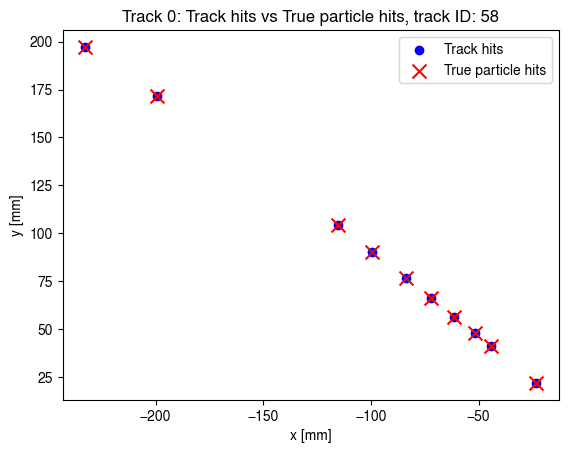

In [61]:
track_index = 0
track_hit_ids = track_hits_df.iloc[track_index].hit_ids

plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {tracks_df.track_id.iloc[track_index]}")

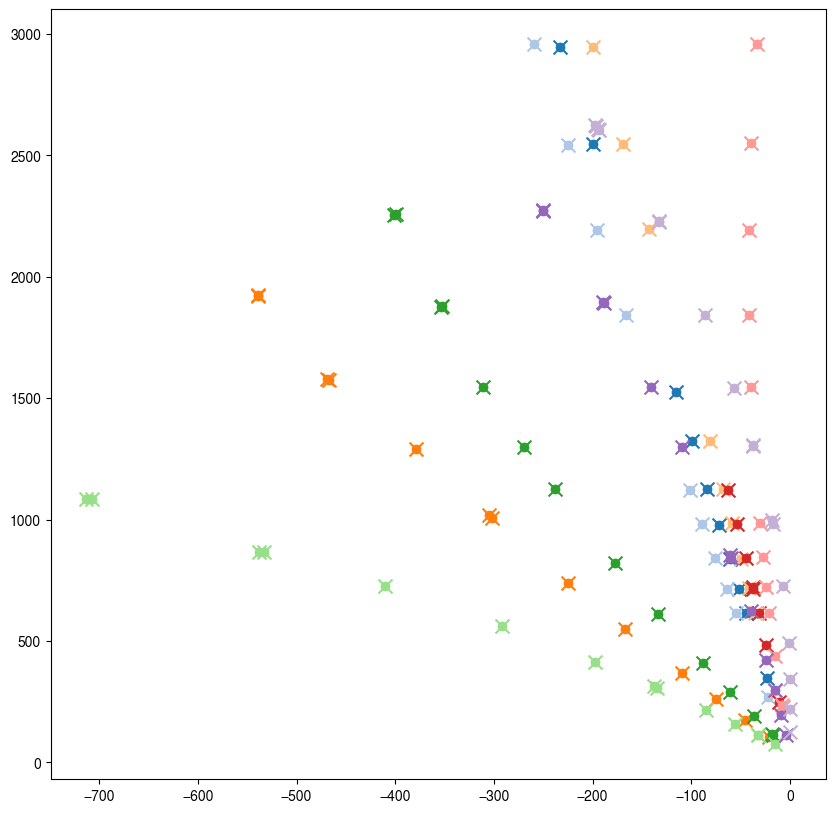

In [62]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

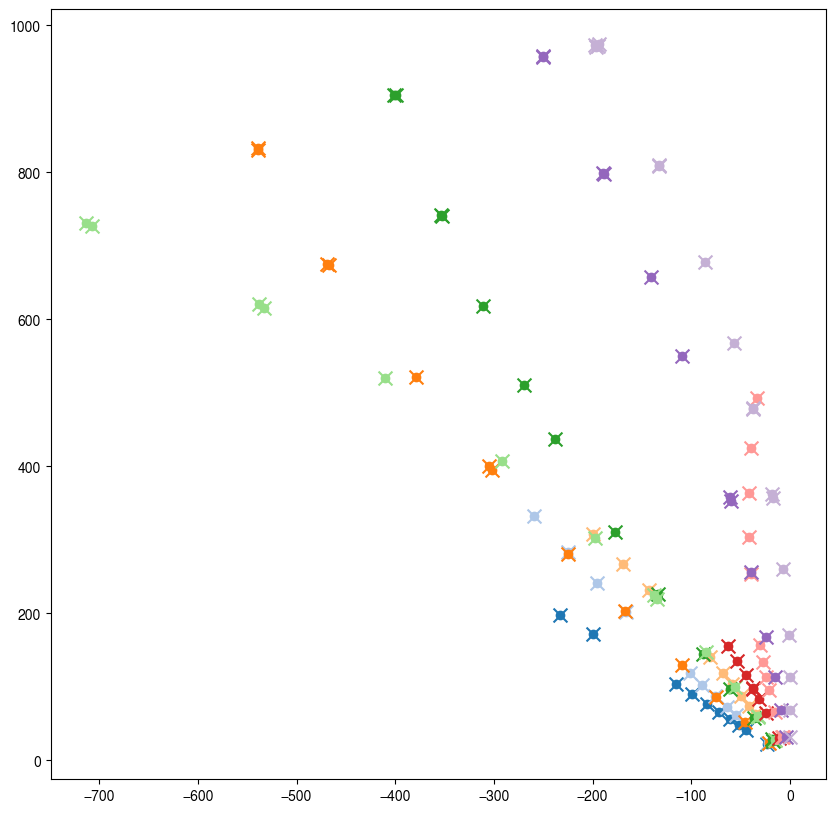

In [63]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

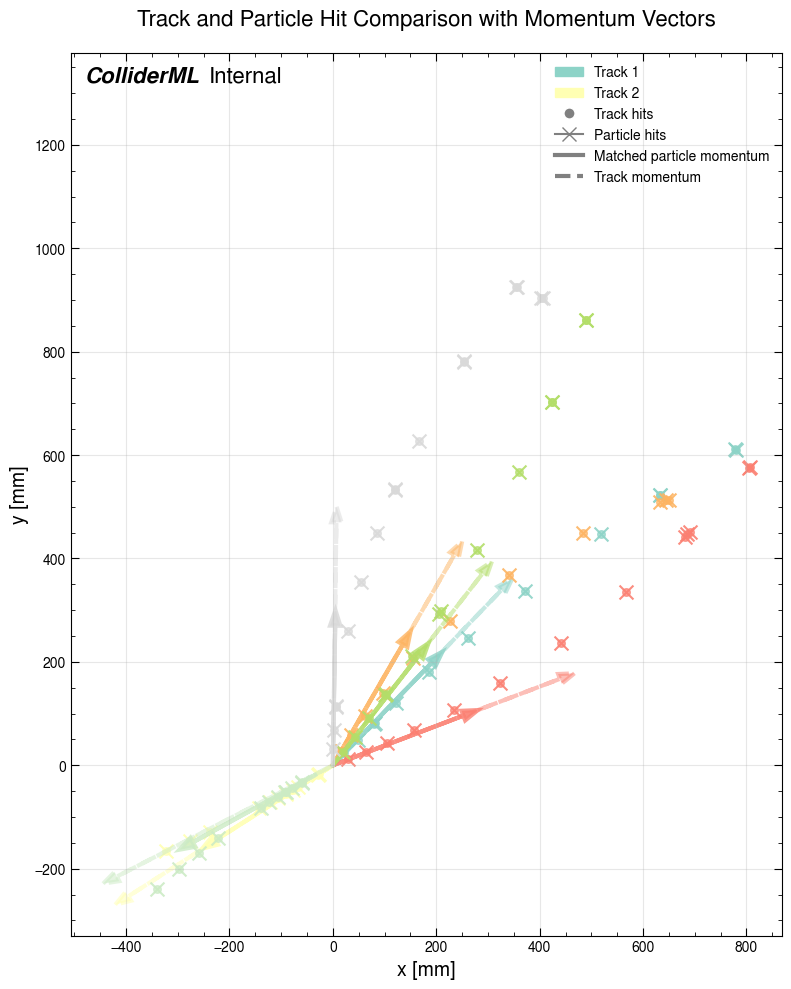

In [64]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()
